# EDA 1 | Parte 3.1 - Análise dos Textos dos Hinos da ICM
Este notebook explora o conteúdo textual dos hinos da coletânea principal da Igreja Cristã Maranata.

O objetivo é analisar o texto dos louvores, extraindo informações como número de palavras, tokens, frequências, n-grams e similaridade entre hinos.

---
**Conteúdo do notebook:**
- Carregamento dos dados tratados
- Tokenização e remoção de stopwords
- Análise do número de palavras por hino
- Visualização da distribuição de tokens por categoria
- Análise de palavras mais longas e frequentes
- Geração de nuvem de palavras

---

**A seguir:** Importação e preparação da lista de stopwords, combinando fontes externas e do NLTK para uso na tokenização.

In [1]:
import pandas as pd
from pathlib import Path

assets_folder = Path("../assets")
hinos_analise: pd.DataFrame = pd.read_pickle(assets_folder / "hinos_analise.pkl")
hinos_analise = hinos_analise.set_index("numero")
hinos_analise["categoria_abr"] = hinos_analise["categoria"].apply(
    lambda x: x[:13] + "..." if len(x) > 15 else x
)
hinos_analise.head()

,nome,texto,texto_processado,categoria_id,categoria,categoria_abr
numero,,,,,,
0,AQUILO QUE FUI NÃO SOU MAIS,"AQUILO QUE FUI NÃO SOU MAIS,\nNEM SOU TUDO O Q...","AQUILO QUE FUI NÃO SOU MAIS,\nNEM SOU TUDO O Q...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...
1,O SANGUE DE JESUS TEM PODER,"O SANGUE DE JESUS TEM PODER,\nPODER QUE A MIM ...","O SANGUE DE JESUS TEM PODER,\nPODER QUE A MIM ...",1.0,CLAMOR,CLAMOR
2,O SANGUE DE JESUS TEM PODER PARA SALVAR,O SANGUE DE JESUS TEM PODER (2x)\nO SANGUE DE ...,O SANGUE DE JESUS TEM PODER <bis tipo='2'>\nO ...,1.0,CLAMOR,CLAMOR
3,CLAMO A TI,"CLAMO A TI, Ó MEU SENHOR,\nCLAMO A TI, MEU SAL...","CLAMO A TI, Ó MEU SENHOR,<bis>\nCLAMO A TI, ME...",1.0,CLAMOR,CLAMOR
4,QUANDO TE PROSTRARES,"QUANDO TE PROSTRARES DIANTE DE DEUS,\nLEMBRA Q...","QUANDO TE PROSTRARES DIANTE DE DEUS,<bis>\nLEM...",1.0,CLAMOR,CLAMOR


---

## Tokenização

**A seguir:** Tokenização dos textos dos hinos, remoção de stopwords e pontuação, e cálculo do número total de palavras por hino.

In [2]:
import nltk

nltk.download("stopwords")
stopwords_nltk = nltk.corpus.stopwords.words("portuguese")

with open(assets_folder / "stopwords-br.txt", "r", encoding="utf-8") as f:
    stopwords = f.read().splitlines()

# remover linhas que comecao com #
stopwords = [eval(word) for word in stopwords if not word.startswith("#")]
stopwords.extend(["ó", "ti", "pra", "lo", "oh", "és"])

# merge
stopwords = list(set(stopwords + stopwords_nltk))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lucas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [30]:
from tqdm import tqdm
import re


all_tokens = []
all_tokens_no_stops = []

# Remoção de tags, novas linhas
hinos_analise["texto_limpo"] = hinos_analise["texto_processado"].astype(str).str.replace(r"<.*?>", "", regex=True)
hinos_analise["texto_unico"] = hinos_analise["texto_limpo"].apply(lambda x: " ".join(list(dict.fromkeys(x.split(r"\n")))))
hinos_analise["texto_limpo"] = hinos_analise["texto_limpo"].str.replace(
    r"\n", " ", regex=False
)
hinos_analise["texto_limpo"] = hinos_analise["texto_limpo"].str.replace(
    r"\s+", " ", regex=True
)
hinos_analise["texto_unico"] = hinos_analise["texto_unico"].str.replace(
    r"\s+", " ", regex=True
)

In [32]:
for hino in tqdm(hinos_analise.to_dict("records")):
    # Tokenização usando regex para extrair apenas palavras
    tokens = nltk.tokenize.regexp_tokenize(hino["texto_limpo"], r"\w+")
    # Replace "MINH" com "MINHA" usando regex
    tokens = [nltk.re.sub(r"^minh$", "minha", palavra.lower()) for palavra in tokens]
    # versão de tokens sem repetição
    tokens_unico = nltk.tokenize.regexp_tokenize(hino["texto_unico"], r"\w+")
    # Replace "MINH" com "MINHA" usando regex
    tokens_unico = [nltk.re.sub(r"^minh$", "minha", palavra.lower()) for palavra in tokens_unico]
    tokens_no_stops = [
        palavra for palavra in tokens_unico if palavra.lower() not in stopwords
    ]
    # remover pontuacao
    tokens = [palavra for palavra in tokens if palavra.isalpha()]
    tokens_no_stops = [palavra for palavra in tokens_no_stops if palavra.isalpha()]

    all_tokens.append(tokens)
    all_tokens_no_stops.append(tokens_no_stops)

hinos_analise["tokens"] = all_tokens
hinos_analise["tokens_no_stops"] = all_tokens_no_stops
# considerando numero total de palavras, pois todas elas tem que ser cantadas, logo impactam no tamanho prático do hino
hinos_analise["num_tokens"] = hinos_analise["tokens"].apply(len)
hinos_analise["num_tokens_unico"] = hinos_analise["tokens_no_stops"].apply(len)
hinos_analise.head()

100%|██████████| 795/795 [00:02<00:00, 317.92it/s]


,nome,texto,texto_processado,categoria_id,categoria,categoria_abr,texto_limpo,tokens,tokens_no_stops,num_tokens,texto_unico,num_tokens_unico
numero,,,,,,,,,,,,
0,AQUILO QUE FUI NÃO SOU MAIS,"AQUILO QUE FUI NÃO SOU MAIS,\nNEM SOU TUDO O Q...","AQUILO QUE FUI NÃO SOU MAIS,\nNEM SOU TUDO O Q...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"AQUILO QUE FUI NÃO SOU MAIS, NEM SOU TUDO O QU...","[aquilo, que, fui, não, sou, mais, nem, sou, t...","[tudo, devo, graça, vê, certo, vou, glória, cr...",124,"AQUILO QUE FUI NÃO SOU MAIS, NEM SOU TUDO O QU...",45
1,O SANGUE DE JESUS TEM PODER,"O SANGUE DE JESUS TEM PODER,\nPODER QUE A MIM ...","O SANGUE DE JESUS TEM PODER,\nPODER QUE A MIM ...",1.0,CLAMOR,CLAMOR,"O SANGUE DE JESUS TEM PODER, PODER QUE A MIM P...","[o, sangue, de, jesus, tem, poder, poder, que,...","[sangue, jesus, pode, valer, comunhão, posso, ...",110,"O SANGUE DE JESUS TEM PODER, PODER QUE A MIM P...",29
2,O SANGUE DE JESUS TEM PODER PARA SALVAR,O SANGUE DE JESUS TEM PODER (2x)\nO SANGUE DE ...,O SANGUE DE JESUS TEM PODER <bis tipo='2'>\nO ...,1.0,CLAMOR,CLAMOR,"O SANGUE DE JESUS TEM PODER O SANGUE DE JESUS,...","[o, sangue, de, jesus, tem, poder, o, sangue, ...","[sangue, jesus, sangue, jesus, sangue, jesus, ...",50,"O SANGUE DE JESUS TEM PODER O SANGUE DE JESUS,...",20
3,CLAMO A TI,"CLAMO A TI, Ó MEU SENHOR,\nCLAMO A TI, MEU SAL...","CLAMO A TI, Ó MEU SENHOR,<bis>\nCLAMO A TI, ME...",1.0,CLAMOR,CLAMOR,"CLAMO A TI, Ó MEU SENHOR, CLAMO A TI, MEU SALV...","[clamo, a, ti, ó, meu, senhor, clamo, a, ti, m...","[clamo, senhor, clamo, salvador, sangue, vida,...",41,"CLAMO A TI, Ó MEU SENHOR, CLAMO A TI, MEU SALV...",17
4,QUANDO TE PROSTRARES,"QUANDO TE PROSTRARES DIANTE DE DEUS,\nLEMBRA Q...","QUANDO TE PROSTRARES DIANTE DE DEUS,<bis>\nLEM...",1.0,CLAMOR,CLAMOR,"QUANDO TE PROSTRARES DIANTE DE DEUS, LEMBRA QU...","[quando, te, prostrares, diante, de, deus, lem...","[prostrares, diante, deus, lembra, jesus, pede...",51,"QUANDO TE PROSTRARES DIANTE DE DEUS, LEMBRA QU...",21


---

**A seguir:** Exibição dos 10 hinos com maior e menor quantidade de palavras, destacando extremos do corpus.

In [33]:
display(hinos_analise.sort_values("num_tokens", ascending=False).head(10))
display(hinos_analise.sort_values("num_tokens", ascending=True).head(10))

,nome,texto,texto_processado,categoria_id,categoria,categoria_abr,texto_limpo,tokens,tokens_no_stops,num_tokens,texto_unico,num_tokens_unico
numero,,,,,,,,,,,,
459,"É TEMPO, É TEMPO","É TEMPO, É TEMPO, \nO MESTRE ESTÁ CHAMANDO JÁ!...","É TEMPO, É TEMPO, \nO MESTRE ESTÁ CHAMANDO JÁ!...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"É TEMPO, É TEMPO, O MESTRE ESTÁ CHAMANDO JÁ! M...","[é, tempo, é, tempo, o, mestre, está, chamando...","[tempo, tempo, mestre, chamando, marchar, marc...",345,"É TEMPO, É TEMPO, O MESTRE ESTÁ CHAMANDO JÁ! M...",104
493,"COMO FOI PARA O CÉU, JESUS CRISTO HÁ DE VIR","COMO FOI PARA O CÉU, JESUS CRISTO HÁ DE VIR,\n...","COMO FOI PARA O CÉU, JESUS CRISTO HÁ DE VIR,\n...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"COMO FOI PARA O CÉU, JESUS CRISTO HÁ DE VIR, Q...","[como, foi, para, o, céu, jesus, cristo, há, d...","[céu, jesus, cristo, som, trombeta, ecoar, voz...",273,"COMO FOI PARA O CÉU, JESUS CRISTO HÁ DE VIR, Q...",84
310,MESTRE O MAR SE REVOLTA,"MESTRE, O MAR SE REVOLTA,\nAS ONDAS NOS DÃO PA...","MESTRE, O MAR SE REVOLTA,\nAS ONDAS NOS DÃO PA...",5.0,CONSOLO E ENCORAJAMENTO,CONSOLO E ENC...,"MESTRE, O MAR SE REVOLTA, AS ONDAS NOS DÃO PAV...","[mestre, o, mar, se, revolta, as, ondas, nos, ...","[mestre, mar, revolta, ondas, dão, pavor, céu,...",262,"MESTRE, O MAR SE REVOLTA, AS ONDAS NOS DÃO PAV...",94
731,SEQUÊNCIA DE LOUVORES NO 1,"A\nDESDE O DIA EM QUE ACEITEI JESUS,\nA MINHA ...","A\nDESDE O DIA EM QUE ACEITEI JESUS,<bis>\nA M...",11.0,CORINHOS,CORINHOS,"A DESDE O DIA EM QUE ACEITEI JESUS, A MINHA VI...","[a, desde, o, dia, em, que, aceitei, jesus, a,...","[dia, aceitei, jesus, vida, transformou, agora...",261,"A DESDE O DIA EM QUE ACEITEI JESUS, A MINHA VI...",98
278,A NOVA DO EVANGELHO,A NOVA DO EVANGELHO\nJÁ SE FEZ OUVIR AQUI;\nBO...,A NOVA DO EVANGELHO\nJÁ SE FEZ OUVIR AQUI;\nBO...,4.0,"MORTE, RESSURREIÇÃO E SALVAÇÃO","MORTE, RESSUR...",A NOVA DO EVANGELHO JÁ SE FEZ OUVIR AQUI; BOAS...,"[a, nova, do, evangelho, já, se, fez, ouvir, a...","[nova, evangelho, fez, ouvir, boas, novas, tão...",251,A NOVA DO EVANGELHO JÁ SE FEZ OUVIR AQUI; BOAS...,83
409,EIS MARCHAMOS PARA AQUELE BOM PAÍS,"EIS MARCHAMOS PARA AQUELE BOM PAÍS, \nONDE O C...","EIS MARCHAMOS PARA AQUELE BOM PAÍS, \nONDE O C...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"EIS MARCHAMOS PARA AQUELE BOM PAÍS, ONDE O CRE...","[eis, marchamos, para, aquele, bom, país, onde...","[eis, marchamos, bom, país, crente, sim, crist...",248,"EIS MARCHAMOS PARA AQUELE BOM PAÍS, ONDE O CRE...",92
467,OS GUERREIROS SE PREPARAM,"OS GUERREIROS SE PREPARAM\nPARA A GRANDE LUTA,...","OS GUERREIROS SE PREPARAM\nPARA A GRANDE LUTA,...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"OS GUERREIROS SE PREPARAM PARA A GRANDE LUTA, ...","[os, guerreiros, se, preparam, para, a, grande...","[guerreiros, preparam, grande, luta, jesus, ca...",244,"OS GUERREIROS SE PREPARAM PARA A GRANDE LUTA, ...",79
148,"UMA CERTA VEZ, JESUS CRISTO","UMA CERTA VEZ, JESUS CRISTO, \nPARA UMA GRANDE...","UMA CERTA VEZ, JESUS CRISTO, \nPARA UMA GRANDE...",3.0,DEDICAÇÃO,DEDICAÇÃO,"UMA CERTA VEZ, JESUS CRISTO, PARA UMA GRANDE M...","[uma, certa, vez, jesus, cristo, para, uma, gr...","[certa, vez, jesus, cristo, grande, multidão, ...",239,"UMA CERTA VEZ, JESUS CRISTO, PARA UMA GRANDE M...",90
364,DÁ-ME MAIS FÉ,DÁ-ME MAIS FÉ PRA QUE O MEU CHORO\nSOMENTE EST...,DÁ-ME MAIS FÉ PRA QUE O MEU CHORO\nSOMENTE EST...,5.0,CONSOLO E ENCORAJAMENTO,CONSOLO E ENC...,DÁ-ME MAIS FÉ PRA QUE O MEU CHORO SOMENTE ESTA...,"[dá, me, mais, fé, pra, que, o, meu, choro, so...","[dá, fé, choro, somente, noite, possa, durar, ...",235,DÁ-ME MAIS FÉ PRA QUE O MEU CHORO SOMENTE ESTA...,79


,nome,texto,texto_processado,categoria_id,categoria,categoria_abr,texto_limpo,tokens,tokens_no_stops,num_tokens,texto_unico,num_tokens_unico
numero,,,,,,,,,,,,
15,"CLAMAREI, CLAMAREI","CLAMAREI, CLAMAREI\nPELO SANGUE DE JESUS;\nELE...","CLAMAREI, CLAMAREI\nPELO SANGUE DE JESUS;\nELE...",1.0,CLAMOR,CLAMOR,"CLAMAREI, CLAMAREI PELO SANGUE DE JESUS; ELE É...","[clamarei, clamarei, pelo, sangue, de, jesus, ...","[clamarei, clamarei, sangue, jesus, paz, segur...",15,"CLAMAREI, CLAMAREI PELO SANGUE DE JESUS; ELE É...",9
13,PÕE TEU SANGUE SOBRE MIM,"PÕE TEU SANGUE SOBRE MIM, (BIS)\nPORÇÃO DOBRAD...","PÕE TEU SANGUE SOBRE MIM, <bis>\nPORÇÃO DOBRAD...",1.0,CLAMOR,CLAMOR,"PÕE TEU SANGUE SOBRE MIM, PORÇÃO DOBRADA, Ó SE...","[põe, teu, sangue, sobre, mim, porção, dobrada...","[põe, sangue, porção, dobrada, senhor, dá, põe...",16,"PÕE TEU SANGUE SOBRE MIM, PORÇÃO DOBRADA, Ó SE...",8
19,TEU POVO CLAMA,"TEU POVO CLAMA EM ORAÇÃO \nPELO TEU SANGUE, LI...",TEU POVO CLAMA EM ORAÇÃO <bis>\nPELO TEU SANGU...,1.0,CLAMOR,CLAMOR,"TEU POVO CLAMA EM ORAÇÃO PELO TEU SANGUE, LIBE...","[teu, povo, clama, em, oração, pelo, teu, sang...","[povo, clama, oração, sangue, libertação, peca...",17,"TEU POVO CLAMA EM ORAÇÃO PELO TEU SANGUE, LIBE...",11
192,"JESUS, JESUS, EU TE AMO","JESUS, JESUS, EU TE AMO,\nÓ MEU SALVADOR;\nEU ...","JESUS, JESUS, EU TE AMO,<bis>\nÓ MEU SALVADOR;...",3.0,DEDICAÇÃO,DEDICAÇÃO,"JESUS, JESUS, EU TE AMO, Ó MEU SALVADOR; EU TE...","[jesus, jesus, eu, te, amo, ó, meu, salvador, ...","[jesus, jesus, amo, salvador, quero, espero, s...",18,"JESUS, JESUS, EU TE AMO, Ó MEU SALVADOR; EU TE...",9
738,"GLÓRIA, GLÓRIA","GLÓRIA, GLÓRIA, GLÓRIA \nAO SENHOR JESUS.\nDEL...","GLÓRIA, GLÓRIA, GLÓRIA <bis>\nAO SENHOR JESUS....",11.0,CORINHOS,CORINHOS,"GLÓRIA, GLÓRIA, GLÓRIA AO SENHOR JESUS. DELE É...","[glória, glória, glória, ao, senhor, jesus, de...","[glória, glória, glória, senhor, jesus, glória...",18,"GLÓRIA, GLÓRIA, GLÓRIA AO SENHOR JESUS. DELE É...",9
11,"REVESTE, SENHOR, TEU POVO","REVESTE, SENHOR, TEU POVO \n(SIM, REVESTE)\n\n...","REVESTE, SENHOR, TEU POVO <bis>\n(SIM, REVESTE...",1.0,CLAMOR,CLAMOR,"REVESTE, SENHOR, TEU POVO (SIM, REVESTE) COM O...","[reveste, senhor, teu, povo, sim, reveste, com...","[reveste, senhor, povo, sim, reveste, sangue, ...",19,"REVESTE, SENHOR, TEU POVO (SIM, REVESTE) COM O...",12
743,VENCEDOR SEREI,"VENCEDOR SEREI, (BIS)\nNADA ME ESPANTA, \nA CA...","VENCEDOR SEREI, <bis>\nNADA ME ESPANTA, <bis>\...",11.0,CORINHOS,CORINHOS,"VENCEDOR SEREI, NADA ME ESPANTA, A CAUSA É SAN...","[vencedor, serei, nada, me, espanta, a, causa,...","[vencedor, nada, espanta, causa, santa, venced...",21,"VENCEDOR SEREI, NADA ME ESPANTA, A CAUSA É SAN...",8
10,VAMOS LAVAR AS VESTES,VAMOS LAVAR AS VESTES \nNO SANGUE DO CORDEIRO....,VAMOS LAVAR AS VESTES <bis>\nNO SANGUE DO CORD...,1.0,CLAMOR,CLAMOR,VAMOS LAVAR AS VESTES NO SANGUE DO CORDEIRO. Q...,"[vamos, lavar, as, vestes, no, sangue, do, cor...","[lavar, vestes, sangue, cordeiro, jesus, vier,...",22,VAMOS LAVAR AS VESTES NO SANGUE DO CORDEIRO. Q...,14
745,É DEUS QUEM NOS TEM DADO A VITÓRIA,É DEUS QUEM NOS TEM DADO A VITÓRIA (4X)\nALELU...,É DEUS QUEM NOS TEM DADO A VITÓRIA <bis tipo='...,11.0,CORINHOS,CORINHOS,"É DEUS QUEM NOS TEM DADO A VITÓRIA ALELUIA, AL...","[é, deus, quem, nos, tem, dado, a, vitória, al...","[deus, dado, vitória, aleluia, aleluia, alelui...",22,"É DEUS QUEM NOS TEM DADO A VITÓRIA ALELUIA, AL...",9


---

**A seguir:** Exibição dos 10 hinos com maior e menor quantidade de palavras sem repetições e stopwords.

In [34]:
display(hinos_analise.sort_values("num_tokens_unico", ascending=False).head(10))
display(hinos_analise.sort_values("num_tokens_unico", ascending=True).head(10))

,nome,texto,texto_processado,categoria_id,categoria,categoria_abr,texto_limpo,tokens,tokens_no_stops,num_tokens,texto_unico,num_tokens_unico
numero,,,,,,,,,,,,
459,"É TEMPO, É TEMPO","É TEMPO, É TEMPO, \nO MESTRE ESTÁ CHAMANDO JÁ!...","É TEMPO, É TEMPO, \nO MESTRE ESTÁ CHAMANDO JÁ!...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"É TEMPO, É TEMPO, O MESTRE ESTÁ CHAMANDO JÁ! M...","[é, tempo, é, tempo, o, mestre, está, chamando...","[tempo, tempo, mestre, chamando, marchar, marc...",345,"É TEMPO, É TEMPO, O MESTRE ESTÁ CHAMANDO JÁ! M...",104
731,SEQUÊNCIA DE LOUVORES NO 1,"A\nDESDE O DIA EM QUE ACEITEI JESUS,\nA MINHA ...","A\nDESDE O DIA EM QUE ACEITEI JESUS,<bis>\nA M...",11.0,CORINHOS,CORINHOS,"A DESDE O DIA EM QUE ACEITEI JESUS, A MINHA VI...","[a, desde, o, dia, em, que, aceitei, jesus, a,...","[dia, aceitei, jesus, vida, transformou, agora...",261,"A DESDE O DIA EM QUE ACEITEI JESUS, A MINHA VI...",98
310,MESTRE O MAR SE REVOLTA,"MESTRE, O MAR SE REVOLTA,\nAS ONDAS NOS DÃO PA...","MESTRE, O MAR SE REVOLTA,\nAS ONDAS NOS DÃO PA...",5.0,CONSOLO E ENCORAJAMENTO,CONSOLO E ENC...,"MESTRE, O MAR SE REVOLTA, AS ONDAS NOS DÃO PAV...","[mestre, o, mar, se, revolta, as, ondas, nos, ...","[mestre, mar, revolta, ondas, dão, pavor, céu,...",262,"MESTRE, O MAR SE REVOLTA, AS ONDAS NOS DÃO PAV...",94
539,"JUNTO AO TRONO DE DEUS, PREPARADO","JUNTO AO TRONO DE DEUS PREPARADO\nHÁ, CRISTÃO,...","JUNTO AO TRONO DE DEUS PREPARADO\nHÁ, CRISTÃO,...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"JUNTO AO TRONO DE DEUS PREPARADO HÁ, CRISTÃO, ...","[junto, ao, trono, de, deus, preparado, há, cr...","[junto, trono, deus, preparado, cristão, lugar...",170,"JUNTO AO TRONO DE DEUS PREPARADO HÁ, CRISTÃO, ...",93
409,EIS MARCHAMOS PARA AQUELE BOM PAÍS,"EIS MARCHAMOS PARA AQUELE BOM PAÍS, \nONDE O C...","EIS MARCHAMOS PARA AQUELE BOM PAÍS, \nONDE O C...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"EIS MARCHAMOS PARA AQUELE BOM PAÍS, ONDE O CRE...","[eis, marchamos, para, aquele, bom, país, onde...","[eis, marchamos, bom, país, crente, sim, crist...",248,"EIS MARCHAMOS PARA AQUELE BOM PAÍS, ONDE O CRE...",92
148,"UMA CERTA VEZ, JESUS CRISTO","UMA CERTA VEZ, JESUS CRISTO, \nPARA UMA GRANDE...","UMA CERTA VEZ, JESUS CRISTO, \nPARA UMA GRANDE...",3.0,DEDICAÇÃO,DEDICAÇÃO,"UMA CERTA VEZ, JESUS CRISTO, PARA UMA GRANDE M...","[uma, certa, vez, jesus, cristo, para, uma, gr...","[certa, vez, jesus, cristo, grande, multidão, ...",239,"UMA CERTA VEZ, JESUS CRISTO, PARA UMA GRANDE M...",90
431,CRISTO JÁ NOS PREPAROU,CRISTO JÁ NOS PREPAROU\nUM MANJAR QUE NOS COMP...,CRISTO JÁ NOS PREPAROU\nUM MANJAR QUE NOS COMP...,6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,CRISTO JÁ NOS PREPAROU UM MANJAR QUE NOS COMPR...,"[cristo, já, nos, preparou, um, manjar, que, n...","[cristo, preparou, manjar, comprou, agora, con...",231,CRISTO JÁ NOS PREPAROU UM MANJAR QUE NOS COMPR...,89
693,"DORMINDO NO MEU LEITO (JERUSALÉM, CIDADE SANTA)","DORMINDO NO MEU LEITO,\nEM SONHO ENCANTADOR,\n...","DORMINDO NO MEU LEITO,\nEM SONHO ENCANTADOR,\n...",10.0,GRUPO DE LOUVOR,GRUPO DE LOUVOR,"DORMINDO NO MEU LEITO, EM SONHO ENCANTADOR, UM...","[dormindo, no, meu, leito, em, sonho, encantad...","[dormindo, leito, sonho, encantador, dia, vi, ...",164,"DORMINDO NO MEU LEITO, EM SONHO ENCANTADOR, UM...",89
497,"JESUS, SIM, VEM, DO CÉU EM GLÓRIA ELE VEM","JESUS, SIM, VEM, DO CÉU EM GLÓRIA ELE VEM, \nE...","JESUS, SIM, VEM, DO CÉU EM GLÓRIA ELE VEM, \nE...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"JESUS, SIM, VEM, DO CÉU EM GLÓRIA ELE VEM, ECO...","[jesus, sim, vem, do, céu, em, glória, ele, ve...","[jesus, sim, vem, céu, glória, vem, ecoa, nova...",200,"JESUS, SIM, VEM, DO CÉU EM GLÓRIA ELE VEM, ECO...",86


,nome,texto,texto_processado,categoria_id,categoria,categoria_abr,texto_limpo,tokens,tokens_no_stops,num_tokens,texto_unico,num_tokens_unico
numero,,,,,,,,,,,,
763,JESUS É TUDO PRA MIM,JESUS É TUDO PRA MIM. \nELE É TUDO PRA MIM.\nJ...,JESUS É TUDO PRA MIM.\nELE É TUDO PRA MIM.\nJE...,11.0,CORINHOS,CORINHOS,JESUS É TUDO PRA MIM. ELE É TUDO PRA MIM. JESU...,"[jesus, é, tudo, pra, mim, ele, é, tudo, pra, ...","[jesus, tudo, tudo, jesus, tesouro, guardado, ...",25,JESUS É TUDO PRA MIM. ELE É TUDO PRA MIM. JESU...,7
735,SEU NOME É JESUS,"SEU NOME É JESUS, (3X)\nEU O AMO SIM.\n\nOH! Q...","SEU NOME É JESUS, <bis tipo='3'>\nEU O AMO SIM...",11.0,CORINHOS,CORINHOS,"SEU NOME É JESUS, EU O AMO SIM. OH! QUANTO O A...","[seu, nome, é, jesus, eu, o, amo, sim, oh, qua...","[nome, jesus, amo, sim, quanto, adoro, rendo]",24,"SEU NOME É JESUS, EU O AMO SIM. OH! QUANTO O A...",7
88,DAS PROFUNDEZAS,"DAS PROFUNDEZAS \nCLAMO A TI, Ó SENHOR,\nÉS A ...","DAS PROFUNDEZAS <bis>\nCLAMO A TI, Ó SENHOR,<b...",2.0,INVOCAÇÃO E COMUNHÃO,INVOCAÇÃO E C...,"DAS PROFUNDEZAS CLAMO A TI, Ó SENHOR, ÉS A MIN...","[das, profundezas, clamo, a, ti, ó, senhor, és...","[profundezas, clamo, senhor, força, rocha, alt...",22,"DAS PROFUNDEZAS CLAMO A TI, Ó SENHOR, ÉS A MIN...",8
13,PÕE TEU SANGUE SOBRE MIM,"PÕE TEU SANGUE SOBRE MIM, (BIS)\nPORÇÃO DOBRAD...","PÕE TEU SANGUE SOBRE MIM, <bis>\nPORÇÃO DOBRAD...",1.0,CLAMOR,CLAMOR,"PÕE TEU SANGUE SOBRE MIM, PORÇÃO DOBRADA, Ó SE...","[põe, teu, sangue, sobre, mim, porção, dobrada...","[põe, sangue, porção, dobrada, senhor, dá, põe...",16,"PÕE TEU SANGUE SOBRE MIM, PORÇÃO DOBRADA, Ó SE...",8
743,VENCEDOR SEREI,"VENCEDOR SEREI, (BIS)\nNADA ME ESPANTA, \nA CA...","VENCEDOR SEREI, <bis>\nNADA ME ESPANTA, <bis>\...",11.0,CORINHOS,CORINHOS,"VENCEDOR SEREI, NADA ME ESPANTA, A CAUSA É SAN...","[vencedor, serei, nada, me, espanta, a, causa,...","[vencedor, nada, espanta, causa, santa, venced...",21,"VENCEDOR SEREI, NADA ME ESPANTA, A CAUSA É SAN...",8
495,"O QUE HÁ DE VIR, VIRÁ","O QUE HÁ DE VIR, VIRÁ, (BIS)\nNÃO TARDARÁ, NÃO...","O QUE HÁ DE VIR, VIRÁ, <bis>\nNÃO TARDARÁ, NÃO...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"O QUE HÁ DE VIR, VIRÁ, NÃO TARDARÁ, NÃO TARDAR...","[o, que, há, de, vir, virá, não, tardará, não,...","[virá, tardará, tardará, jesus, virá, fiéis, s...",46,"O QUE HÁ DE VIR, VIRÁ, NÃO TARDARÁ, NÃO TARDAR...",8
401,COMO TU QUERES,"COMO TU QUERES, SENHOR, SOU TEU\nTU ÉS OLEIRO,...","COMO TU QUERES, SENHOR, SOU TEU\nTU ÉS OLEIRO,...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"COMO TU QUERES, SENHOR, SOU TEU TU ÉS OLEIRO, ...","[como, tu, queres, senhor, sou, teu, tu, és, o...","[queres, senhor, oleiro, vaso, quebra, transfo...",24,"COMO TU QUERES, SENHOR, SOU TEU TU ÉS OLEIRO, ...",9
15,"CLAMAREI, CLAMAREI","CLAMAREI, CLAMAREI\nPELO SANGUE DE JESUS;\nELE...","CLAMAREI, CLAMAREI\nPELO SANGUE DE JESUS;\nELE...",1.0,CLAMOR,CLAMOR,"CLAMAREI, CLAMAREI PELO SANGUE DE JESUS; ELE É...","[clamarei, clamarei, pelo, sangue, de, jesus, ...","[clamarei, clamarei, sangue, jesus, paz, segur...",15,"CLAMAREI, CLAMAREI PELO SANGUE DE JESUS; ELE É...",9
738,"GLÓRIA, GLÓRIA","GLÓRIA, GLÓRIA, GLÓRIA \nAO SENHOR JESUS.\nDEL...","GLÓRIA, GLÓRIA, GLÓRIA <bis>\nAO SENHOR JESUS....",11.0,CORINHOS,CORINHOS,"GLÓRIA, GLÓRIA, GLÓRIA AO SENHOR JESUS. DELE É...","[glória, glória, glória, ao, senhor, jesus, de...","[glória, glória, glória, senhor, jesus, glória...",18,"GLÓRIA, GLÓRIA, GLÓRIA AO SENHOR JESUS. DELE É...",9


---

**A seguir:** Visualização da distribuição do número de palavras por categoria, utilizando boxplot para identificar padrões e variações.

C:\Users\lucas\AppData\Local\Temp\ipykernel_12488\1516382572.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


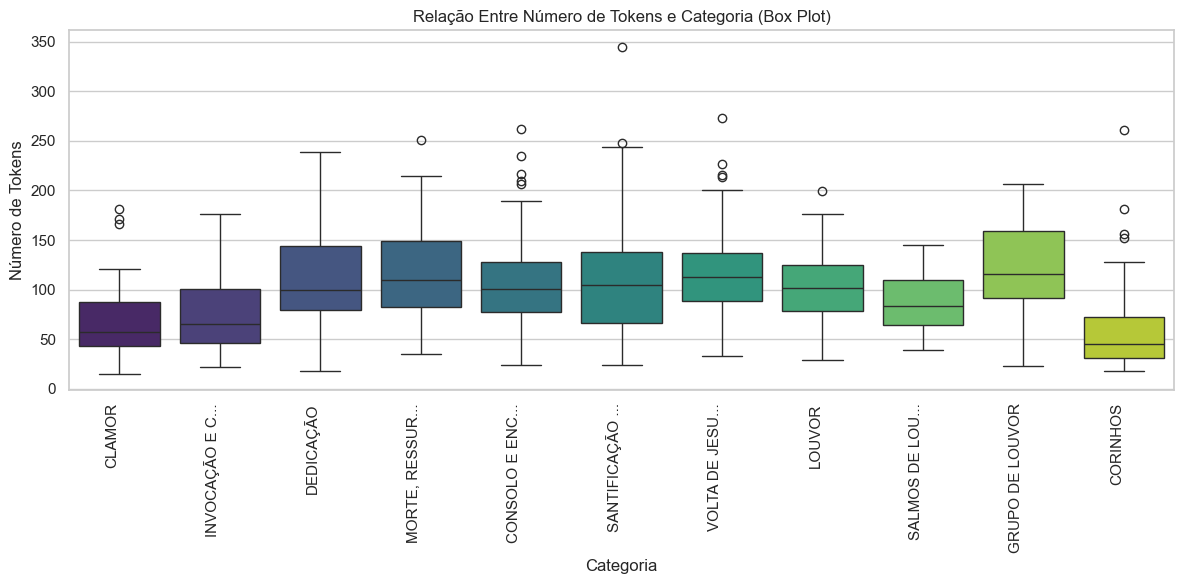

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Garantir que 'categoria_id' seja numérico para ordenar corretamente no eixo x
hinos_analise["categoria_id"] = pd.to_numeric(hinos_analise["categoria_id"], errors="coerce")

# Ordem explícita das categorias (evita ordem incorreta do tipo categórico)
categoria_order = sorted(hinos_analise["categoria_id"].dropna().unique())

# Mapeamento entre categoria_id e nome abreviado da categoria
categoria_mapping = (
    hinos_analise[["categoria_id", "categoria_abr"]]
    .dropna(subset=["categoria_id"])
    .drop_duplicates(subset=["categoria_id"])
    .set_index("categoria_id")["categoria_abr"]
)

# Criar boxplot com ordem fixa de categoria_id
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=hinos_analise,
    x="categoria_id",
    y="num_tokens",
    order=categoria_order,
    palette="viridis",
)

# Rótulos no eixo x seguindo a mesma ordem do plot
plt.xticks(
    ticks=range(len(categoria_order)),
    labels=[categoria_mapping.get(cat, str(int(cat))) for cat in categoria_order],
    rotation=90,
    ha="right",
)

# Adiciona labels e titulo
plt.xlabel("Categoria")
plt.ylabel("Número de Tokens")
plt.title("Relação Entre Número de Tokens e Categoria (Box Plot)")

plt.tight_layout()
plt.show()

---

**A seguir:** Análise de palavras: extração, identificação das mais longas, contagem de frequência e visualização das palavras mais comuns com nuvem de palavras e gráfico de barras.

## Histograma de frequência de tamanho das palavras

**A seguir:** Geração de um histograma mostrando a frequência dos tamanhos das palavras nos textos dos hinos, para entender a distribuição do comprimento das palavras utilizadas.

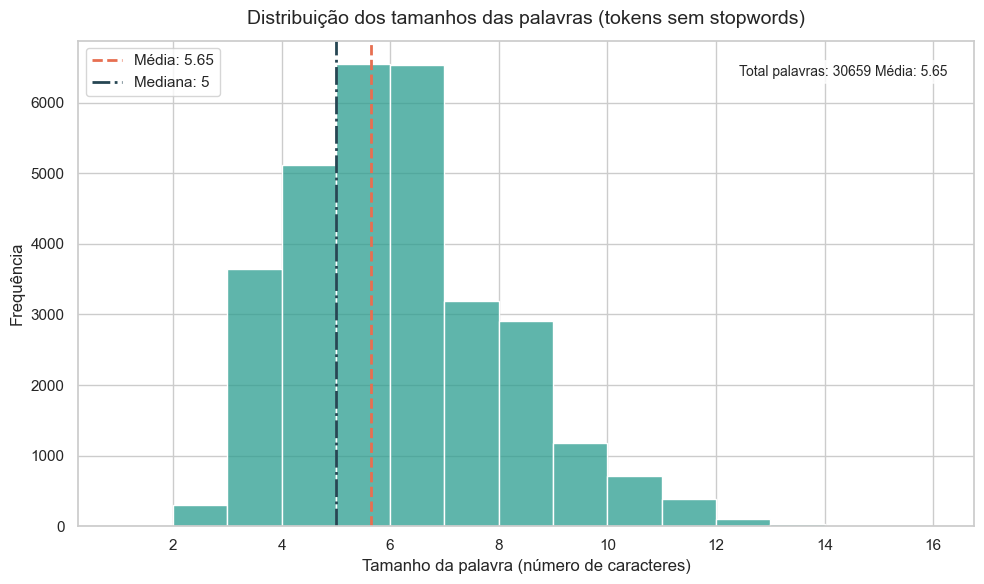

In [36]:
# Histograma mais apresentável: distribuição do tamanho das palavras (tokens sem stopwords)
import numpy as np
import seaborn as sns

# Extrair tamanhos das palavras (tratando casos vazios)
palavras_explodidas = hinos_analise["tokens_no_stops"].explode().dropna().tolist()
line_num_words = [
    len(p) for p in palavras_explodidas if isinstance(p, str) and p.strip() != ""
]

# Configurar estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Histogram + KDE
ax = sns.histplot(
    line_num_words, bins=range(1, max(line_num_words) + 2), color="#2a9d8f"
)

# Estatísticas
media = np.mean(line_num_words)
mediana = np.median(line_num_words)

# Linhas de média e mediana
ax.axvline(
    media, color="#e76f51", linestyle="--", linewidth=2, label=f"Média: {media:.2f}"
)
ax.axvline(
    mediana,
    color="#264653",
    linestyle="-.",
    linewidth=2,
    label=f"Mediana: {mediana:.0f}",
)

# Labels e título em português
ax.set_xlabel("Tamanho da palavra (número de caracteres)", fontsize=12)
ax.set_ylabel("Frequência", fontsize=12)
ax.set_title(
    "Distribuição dos tamanhos das palavras (tokens sem stopwords)", fontsize=14, pad=12
)

# Anotações: número total de palavras e modo
total = len(line_num_words)
props = dict(boxstyle="round", facecolor="white", alpha=0.8)
ax.text(
    0.97,
    0.95,
    f"Total palavras: {total} Média: {media:.2f}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=props,
)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## Palavras mais longas

**A seguir:** Exibição das 10 palavras mais longas encontradas nos textos dos hinos, destacando a diversidade lexical do corpus.

In [37]:
palavras = hinos_analise["tokens_no_stops"].explode().tolist()

# find the 10 largest words
palavras_unique = list(set(palavras))
palavras_unique.sort(key=len, reverse=True)
print("Quantidade de palavras únicas (sem repetição):", len(palavras_unique))
pd.DataFrame(
    {
        "palavra": palavras_unique[:10],
        "tamanho": [len(palavra) for palavra in palavras_unique[:10]],
    }
)

Quantidade de palavras únicas (sem repetição): 4555


,palavra,tamanho
0,sobrecarregados,15
1,espiritualmente,15
2,circunstâncias,14
3,carinhosamente,14
4,sobrecarregado,14
5,proporcionando,14
6,reverentemente,14
7,resplandecente,14
8,ensanguentada,13
9,misericórdias,13


## Bag-of-words

**A seguir:** Criação de uma representação bag-of-words dos textos dos hinos, incluindo a frequência de cada palavra e um mapeamento das palavras para seus índices.

In [38]:
print("Total de palavras:", len(palavras))
set_words_full = list(set(palavras))
count_words = [palavras.count(i) for i in set_words_full]

contagem_palav = pd.DataFrame(
    zip(set_words_full, count_words), columns=["palavra", "contagem"]
)
contagem_palav = contagem_palav.sort_values("contagem", ascending=False)
contagem_palav["percentual"] = contagem_palav["contagem"] / len(palavras) * 100
contagem_palav.head(20)

Total de palavras: 30659


,palavra,contagem,percentual
4399,jesus,1114,3.633517
1874,senhor,996,3.248638
2346,deus,693,2.260348
3682,amor,536,1.748263
1619,glória,362,1.180730
3566,vem,353,1.151375
1181,cristo,351,1.144851
3113,vida,339,1.105711
2685,sempre,256,0.834991
2714,céu,236,0.769758


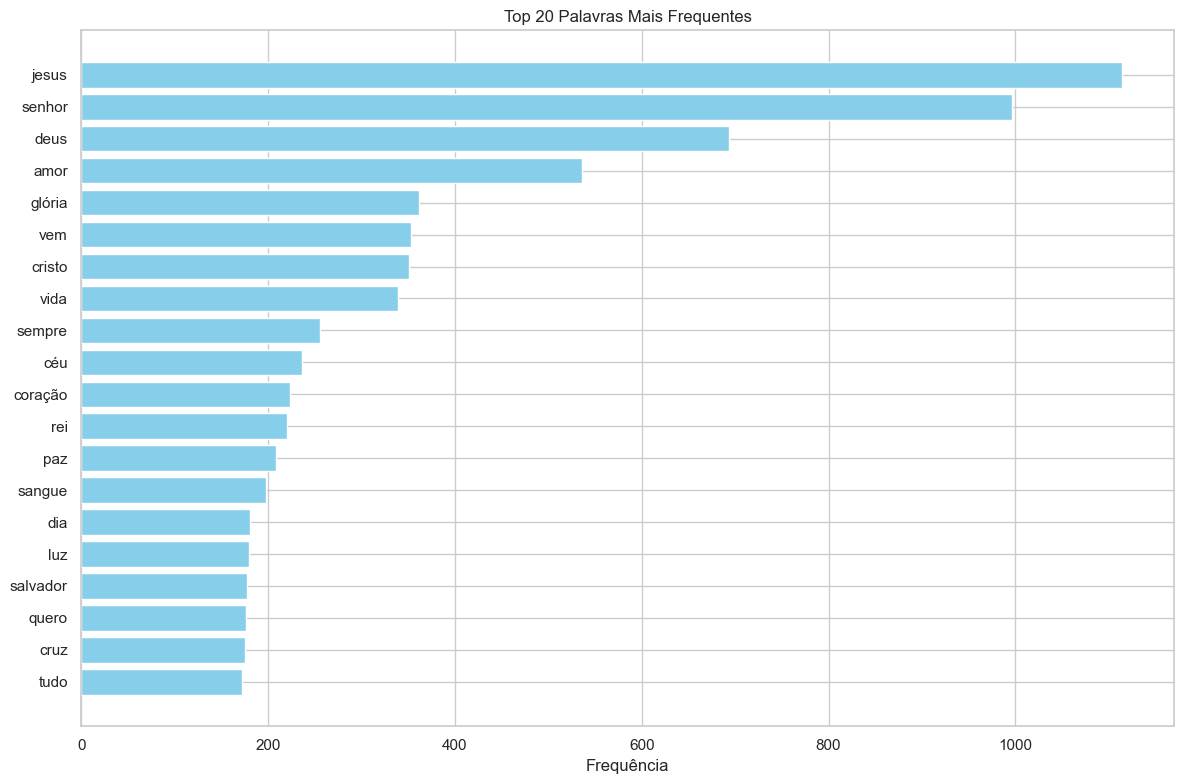

In [39]:
import matplotlib.pyplot as plt

# Also show top 20 most frequent words as a bar chart
plt.figure(figsize=(12, 8))
top_20 = contagem_palav.head(20)
plt.barh(range(len(top_20)), top_20["contagem"], color="skyblue")
plt.yticks(range(len(top_20)), top_20["palavra"])
plt.xlabel("Frequência")
plt.title("Top 20 Palavras Mais Frequentes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Word cloud

**A seguir:** Geração de uma nuvem de palavras para visualizar as palavras mais frequentes nos textos dos hinos, destacando termos recorrentes e temas predominantes.

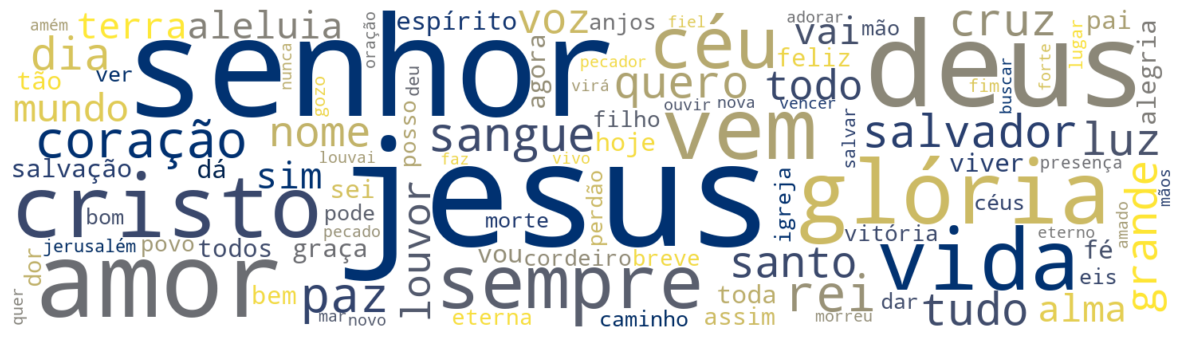

In [42]:
from wordcloud import WordCloud

# Create a dictionary from the word frequency data
word_freq_dict = dict(zip(contagem_palav["palavra"], contagem_palav["contagem"]))

# Generate word cloud
wordcloud = WordCloud(
    width=1460,
    height=400,
    background_color="white",
    max_words=100,
    colormap="cividis",
    relative_scaling=0.5,
    random_state=42,
).generate_from_frequencies(word_freq_dict)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
# plt.title("Word Cloud - Palavras mais frequentes nos hinos", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

---

**A seguir:** Exportação dos dados tratados e enriquecidos para arquivo pickle, permitindo reutilização em outras análises ou notebooks.

In [41]:
hinos_analise.to_pickle(assets_folder / "hinos_analise_tokens.pkl")

## Metadados: tags dos hinos

Uma rápida análise das tags de "coro" e "instrumentos" presentes nos hinos.

In [ ]:
hinos_analise["total_coro"] = hinos_analise["texto_processado"].str.count(r"<coro")
hinos_analise["total_instrumentos"] = hinos_analise["texto_processado"].str.count(
    r"<instrumentos"
)
hinos_analise["total_final"] = hinos_analise["texto_processado"].str.count(
    r"<final"
)

,nome,texto,texto_processado,categoria_id,categoria,categoria_abr,texto_limpo,tokens,tokens_no_stops,num_tokens,texto_unico,num_tokens_unico,total_coro,total_instrumentos,total_final
numero,,,,,,,,,,,,,,,
0,AQUILO QUE FUI NÃO SOU MAIS,"AQUILO QUE FUI NÃO SOU MAIS,\nNEM SOU TUDO O Q...","AQUILO QUE FUI NÃO SOU MAIS,\nNEM SOU TUDO O Q...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"AQUILO QUE FUI NÃO SOU MAIS, NEM SOU TUDO O QU...","[aquilo, que, fui, não, sou, mais, nem, sou, t...","[tudo, devo, graça, vê, certo, vou, glória, cr...",124,"AQUILO QUE FUI NÃO SOU MAIS, NEM SOU TUDO O QU...",45,3,0,0
1,O SANGUE DE JESUS TEM PODER,"O SANGUE DE JESUS TEM PODER,\nPODER QUE A MIM ...","O SANGUE DE JESUS TEM PODER,\nPODER QUE A MIM ...",1.0,CLAMOR,CLAMOR,"O SANGUE DE JESUS TEM PODER, PODER QUE A MIM P...","[o, sangue, de, jesus, tem, poder, poder, que,...","[sangue, jesus, pode, valer, comunhão, posso, ...",110,"O SANGUE DE JESUS TEM PODER, PODER QUE A MIM P...",29,2,0,0
2,O SANGUE DE JESUS TEM PODER PARA SALVAR,O SANGUE DE JESUS TEM PODER (2x)\nO SANGUE DE ...,O SANGUE DE JESUS TEM PODER <bis tipo='2'>\nO ...,1.0,CLAMOR,CLAMOR,"O SANGUE DE JESUS TEM PODER O SANGUE DE JESUS,...","[o, sangue, de, jesus, tem, poder, o, sangue, ...","[sangue, jesus, sangue, jesus, sangue, jesus, ...",50,"O SANGUE DE JESUS TEM PODER O SANGUE DE JESUS,...",20,0,0,0
3,CLAMO A TI,"CLAMO A TI, Ó MEU SENHOR,\nCLAMO A TI, MEU SAL...","CLAMO A TI, Ó MEU SENHOR,<bis>\nCLAMO A TI, ME...",1.0,CLAMOR,CLAMOR,"CLAMO A TI, Ó MEU SENHOR, CLAMO A TI, MEU SALV...","[clamo, a, ti, ó, meu, senhor, clamo, a, ti, m...","[clamo, senhor, clamo, salvador, sangue, vida,...",41,"CLAMO A TI, Ó MEU SENHOR, CLAMO A TI, MEU SALV...",17,0,0,0
4,QUANDO TE PROSTRARES,"QUANDO TE PROSTRARES DIANTE DE DEUS,\nLEMBRA Q...","QUANDO TE PROSTRARES DIANTE DE DEUS,<bis>\nLEM...",1.0,CLAMOR,CLAMOR,"QUANDO TE PROSTRARES DIANTE DE DEUS, LEMBRA QU...","[quando, te, prostrares, diante, de, deus, lem...","[prostrares, diante, deus, lembra, jesus, pede...",51,"QUANDO TE PROSTRARES DIANTE DE DEUS, LEMBRA QU...",21,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790,AQUELE QUE HABITA NO ESCONDERIJO,AQUELE QUE HABITA\nNO ESCONDERIJO DO ALTÍSSIMO...,AQUELE QUE HABITA\nNO ESCONDERIJO DO ALTÍSSIMO...,11.0,CORINHOS,CORINHOS,AQUELE QUE HABITA NO ESCONDERIJO DO ALTÍSSIMO ...,"[aquele, que, habita, no, esconderijo, do, alt...","[habita, esconderijo, altíssimo, sombra, senho...",43,AQUELE QUE HABITA NO ESCONDERIJO DO ALTÍSSIMO ...,16,0,0,1
791,EU QUERO MAIS E MAIS DE CRISTO,EU QUERO MAIS E MAIS DE CRISTO. \nEU QUERO MAI...,EU QUERO MAIS E MAIS DE CRISTO. <bis>\nEU QUER...,11.0,CORINHOS,CORINHOS,EU QUERO MAIS E MAIS DE CRISTO. EU QUERO MAIS ...,"[eu, quero, mais, e, mais, de, cristo, eu, que...","[quero, cristo, quero, quero, presença, quero,...",46,EU QUERO MAIS E MAIS DE CRISTO. EU QUERO MAIS ...,12,0,0,0
792,LOUVANDO A DEUS,LOUVANDO A DEUS \nE CAINDO NA GRAÇA DE TODO O ...,LOUVANDO A DEUS <bis>\nE CAINDO NA GRAÇA DE TO...,11.0,CORINHOS,CORINHOS,LOUVANDO A DEUS E CAINDO NA GRAÇA DE TODO O PO...,"[louvando, a, deus, e, caindo, na, graça, de, ...","[louvando, deus, caindo, graça, todo, povo, to...",26,LOUVANDO A DEUS E CAINDO NA GRAÇA DE TODO O PO...,13,0,0,0


,nome,texto,texto_processado,categoria_id,categoria,categoria_abr,texto_limpo,tokens,tokens_no_stops,num_tokens,texto_unico,num_tokens_unico,total_coro,total_instrumentos,total_final
numero,,,,,,,,,,,,,,,
493,"COMO FOI PARA O CÉU, JESUS CRISTO HÁ DE VIR","COMO FOI PARA O CÉU, JESUS CRISTO HÁ DE VIR,\n...","COMO FOI PARA O CÉU, JESUS CRISTO HÁ DE VIR,\n...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"COMO FOI PARA O CÉU, JESUS CRISTO HÁ DE VIR, Q...","[como, foi, para, o, céu, jesus, cristo, há, d...","[céu, jesus, cristo, som, trombeta, ecoar, voz...",273,"COMO FOI PARA O CÉU, JESUS CRISTO HÁ DE VIR, Q...",84,5,0,0
459,"É TEMPO, É TEMPO","É TEMPO, É TEMPO, \nO MESTRE ESTÁ CHAMANDO JÁ!...","É TEMPO, É TEMPO, \nO MESTRE ESTÁ CHAMANDO JÁ!...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"É TEMPO, É TEMPO, O MESTRE ESTÁ CHAMANDO JÁ! M...","[é, tempo, é, tempo, o, mestre, está, chamando...","[tempo, tempo, mestre, chamando, marchar, marc...",345,"É TEMPO, É TEMPO, O MESTRE ESTÁ CHAMANDO JÁ! M...",104,5,0,0
466,EIS O ESTANDARTE,"EIS O ESTANDARTE TREMULANDO À LUZ,\nEIS A SUA ...","EIS O ESTANDARTE TREMULANDO À LUZ,\nEIS A SUA ...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"EIS O ESTANDARTE TREMULANDO À LUZ, EIS A SUA D...","[eis, o, estandarte, tremulando, à, luz, eis, ...","[eis, estandarte, tremulando, luz, eis, divisa...",226,"EIS O ESTANDARTE TREMULANDO À LUZ, EIS A SUA D...",85,5,0,0
679,EIS A ESCRAVA RESGATADA,EIS A ESCRAVA RESGATADA!\nGRANDE PREÇO CRISTO ...,EIS A ESCRAVA RESGATADA!\nGRANDE PREÇO CRISTO ...,10.0,GRUPO DE LOUVOR,GRUPO DE LOUVOR,EIS A ESCRAVA RESGATADA! GRANDE PREÇO CRISTO D...,"[eis, a, escrava, resgatada, grande, preço, cr...","[eis, escrava, resgatada, grande, preço, crist...",189,EIS A ESCRAVA RESGATADA! GRANDE PREÇO CRISTO D...,59,5,0,0
431,CRISTO JÁ NOS PREPAROU,CRISTO JÁ NOS PREPAROU\nUM MANJAR QUE NOS COMP...,CRISTO JÁ NOS PREPAROU\nUM MANJAR QUE NOS COMP...,6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,CRISTO JÁ NOS PREPAROU UM MANJAR QUE NOS COMPR...,"[cristo, já, nos, preparou, um, manjar, que, n...","[cristo, preparou, manjar, comprou, agora, con...",231,CRISTO JÁ NOS PREPAROU UM MANJAR QUE NOS COMPR...,89,4,0,0
712,AO FINDAR O LABOR DESTA VIDA (A ÚLTIMA HORA),"AO FINDAR O LABOR DESTA VIDA,\nQUANDO A MORTE ...","AO FINDAR O LABOR DESTA VIDA,\nQUANDO A MORTE ...",10.0,GRUPO DE LOUVOR,GRUPO DE LOUVOR,"AO FINDAR O LABOR DESTA VIDA, QUANDO A MORTE A...","[ao, findar, o, labor, desta, vida, quando, a,...","[findar, labor, vida, morte, lado, chegar, des...",187,"AO FINDAR O LABOR DESTA VIDA, QUANDO A MORTE A...",62,4,0,0
347,FIRME NAS PROMESSAS,"FIRME NAS PROMESSAS DO MEU SALVADOR,\nCANTAREI...","FIRME NAS PROMESSAS DO MEU SALVADOR,\nCANTAREI...",5.0,CONSOLO E ENCORAJAMENTO,CONSOLO E ENC...,"FIRME NAS PROMESSAS DO MEU SALVADOR, CANTAREI ...","[firme, nas, promessas, do, meu, salvador, can...","[firme, promessas, salvador, cantarei, louvore...",160,"FIRME NAS PROMESSAS DO MEU SALVADOR, CANTAREI ...",53,4,0,0
345,EM NADA PONHO A MINHA FÉ,"EM NADA PONHO A MINHA FÉ,\nSENÃO NA GRAÇA DE J...","EM NADA PONHO A MINHA FÉ,\nSENÃO NA GRAÇA DE J...",5.0,CONSOLO E ENCORAJAMENTO,CONSOLO E ENC...,"EM NADA PONHO A MINHA FÉ, SENÃO NA GRAÇA DE JE...","[em, nada, ponho, a, minha, fé, senão, na, gra...","[nada, ponho, fé, senão, graça, jesus, sacrifí...",126,"EM NADA PONHO A MINHA FÉ, SENÃO NA GRAÇA DE JE...",45,4,0,0
467,OS GUERREIROS SE PREPARAM,"OS GUERREIROS SE PREPARAM\nPARA A GRANDE LUTA,...","OS GUERREIROS SE PREPARAM\nPARA A GRANDE LUTA,...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"OS GUERREIROS SE PREPARAM PARA A GRANDE LUTA, ...","[os, guerreiros, se, preparam, para, a, grande...","[guerreiros, preparam, grande, luta, jesus, ca...",244,"OS GUERREIROS SE PREPARAM PARA A GRANDE LUTA, ...",79,4,0,0


<Axes: ylabel='Frequency'>

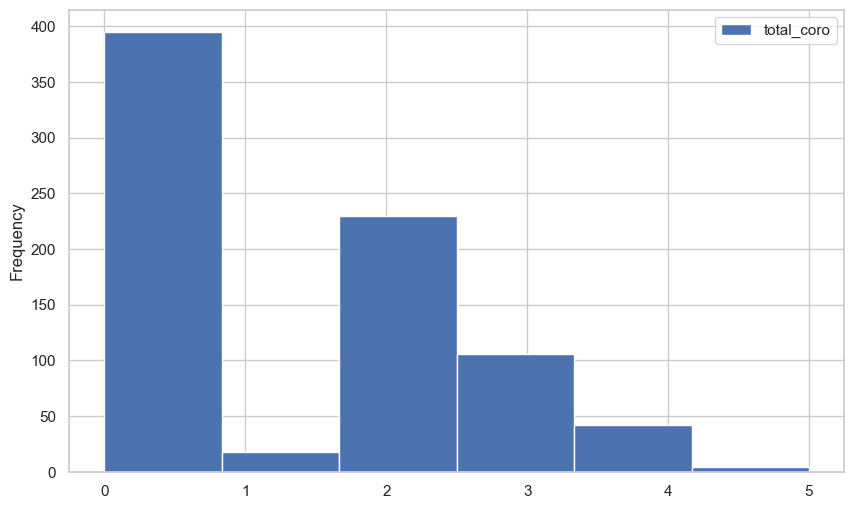

In [55]:
display(hinos_analise.sort_values("total_coro", ascending=False).head(10))
hinos_analise.plot(
    kind="hist",
    y="total_coro",
    bins=len(hinos_analise["total_coro"].unique()),
    figsize=(10, 6),
)

,nome,texto,texto_processado,categoria_id,categoria,categoria_abr,texto_limpo,tokens,tokens_no_stops,num_tokens,texto_unico,num_tokens_unico,total_coro,total_instrumentos,total_final
numero,,,,,,,,,,,,,,,
389,"SENHOR, O QUE É A NOSSA VIDA?","SENHOR, O QUE É A NOSSA VIDA?\nÉ COMO A VIGÍLI...","SENHOR, O QUE É A NOSSA VIDA?\nÉ COMO A VIGÍLI...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"SENHOR, O QUE É A NOSSA VIDA? É COMO A VIGÍLIA...","[senhor, o, que, é, a, nossa, vida, é, como, a...","[senhor, vida, vigília, noite, relva, cedo, fl...",98,"SENHOR, O QUE É A NOSSA VIDA? É COMO A VIGÍLIA...",42,2,5,1
547,"Ó VEM LOGO, JESUS","Ó VEM LOGO, JESUS!\nÓ VEM LOGO, JESUS!\nA MINH...","Ó VEM LOGO, JESUS!\nÓ VEM LOGO, JESUS!\nA MINH...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"Ó VEM LOGO, JESUS! Ó VEM LOGO, JESUS! A MINH'A...","[ó, vem, logo, jesus, ó, vem, logo, jesus, a, ...","[vem, jesus, alma, espera, quanto, almejo, ver...",102,"Ó VEM LOGO, JESUS! A MINH'ALMA TE ESPERA, QUAN...",31,0,3,1
495,"O QUE HÁ DE VIR, VIRÁ","O QUE HÁ DE VIR, VIRÁ, (BIS)\nNÃO TARDARÁ, NÃO...","O QUE HÁ DE VIR, VIRÁ, <bis>\nNÃO TARDARÁ, NÃO...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"O QUE HÁ DE VIR, VIRÁ, NÃO TARDARÁ, NÃO TARDAR...","[o, que, há, de, vir, virá, não, tardará, não,...","[virá, tardará, tardará, jesus, virá, fiéis, s...",46,"O QUE HÁ DE VIR, VIRÁ, NÃO TARDARÁ, NÃO TARDAR...",8,0,3,1
543,AO LADO DE DEUS,"AO LADO DE DEUS QUERO ESTAR,\nNAS MANSÕES QUE ...","AO LADO DE DEUS QUERO ESTAR,\nNAS MANSÕES QUE ...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"AO LADO DE DEUS QUERO ESTAR, NAS MANSÕES QUE E...","[ao, lado, de, deus, quero, estar, nas, mansõe...","[lado, deus, quero, mansões, preparou, ver, fa...",109,"AO LADO DE DEUS QUERO ESTAR, NAS MANSÕES QUE E...",45,2,3,1
714,COM TUA MÃO SEGURA BEM A MINHA (AMPARO DIVINO),"COM TUA MÃO SEGURA BEM A MINHA,\nPOIS EU TÃO F...","COM TUA MÃO SEGURA BEM A MINHA,\nPOIS EU TÃO F...",10.0,GRUPO DE LOUVOR,GRUPO DE LOUVOR,"COM TUA MÃO SEGURA BEM A MINHA, POIS EU TÃO FR...","[com, tua, mão, segura, bem, a, minha, pois, e...","[mão, segura, bem, tão, frágil, salvador, atre...",108,"COM TUA MÃO SEGURA BEM A MINHA, POIS EU TÃO FR...",44,0,3,0
723,CRISTO PODE HOJE VIR (OH! DIA ALEGRE!),"CRISTO PODE HOJE VIR,\nOH! DIA ALEGRE! IREI AM...","CRISTO PODE HOJE VIR,\nOH! DIA ALEGRE! IREI AM...",10.0,GRUPO DE LOUVOR,GRUPO DE LOUVOR,"CRISTO PODE HOJE VIR, OH! DIA ALEGRE! IREI AMI...","[cristo, pode, hoje, vir, oh, dia, alegre, ire...","[cristo, pode, hoje, dia, alegre, irei, amigos...",192,"CRISTO PODE HOJE VIR, OH! DIA ALEGRE! IREI AMI...",59,4,3,0
292,AO SENTIR O MUNDO AO MEU REDOR,"AO SENTIR O MUNDO AO MEU REDOR,\nNADA VI QUE P...","AO SENTIR O MUNDO AO MEU REDOR,\nNADA VI QUE P...",4.0,"MORTE, RESSURREIÇÃO E SALVAÇÃO","MORTE, RESSUR...","AO SENTIR O MUNDO AO MEU REDOR, NADA VI QUE PU...","[ao, sentir, o, mundo, ao, meu, redor, nada, v...","[sentir, mundo, redor, nada, vi, pudesse, real...",132,"AO SENTIR O MUNDO AO MEU REDOR, NADA VI QUE PU...",59,0,2,0
282,QUEM É QUE DÁ ÁGUA AO SEDENTO?,QUEM É QUE DÁ ÁGUA AO SEDENTO \nE UMA SOMBRA F...,QUEM É QUE DÁ ÁGUA AO SEDENTO \nE UMA SOMBRA F...,4.0,"MORTE, RESSURREIÇÃO E SALVAÇÃO","MORTE, RESSUR...",QUEM É QUE DÁ ÁGUA AO SEDENTO E UMA SOMBRA FRE...,"[quem, é, que, dá, água, ao, sedento, e, uma, ...","[dá, água, sedento, sombra, fresca, retira, ho...",157,QUEM É QUE DÁ ÁGUA AO SEDENTO E UMA SOMBRA FRE...,43,3,2,0
444,DESEJEI ARDENTEMENTE,"DESEJEI ARDENTEMENTE\nCONVOSCO CEAR, POVO MEU....","DESEJEI ARDENTEMENTE<bis>\nCONVOSCO CEAR, POVO...",6.0,SANTIFICAÇÃO E DERRAMAMENTO DO ESPÍRITO SANTO,SANTIFICAÇÃO ...,"DESEJEI ARDENTEMENTE CONVOSCO CEAR, POVO MEU. ...","[desejei, ardentemente, convosco, cear, povo, ...","[desejei, ardentemente, convosco, cear, povo, ...",63,"DESEJEI ARDENTEMENTE CONVOSCO CEAR, POVO MEU. ...",29,2,2,1


<Axes: ylabel='Frequency'>

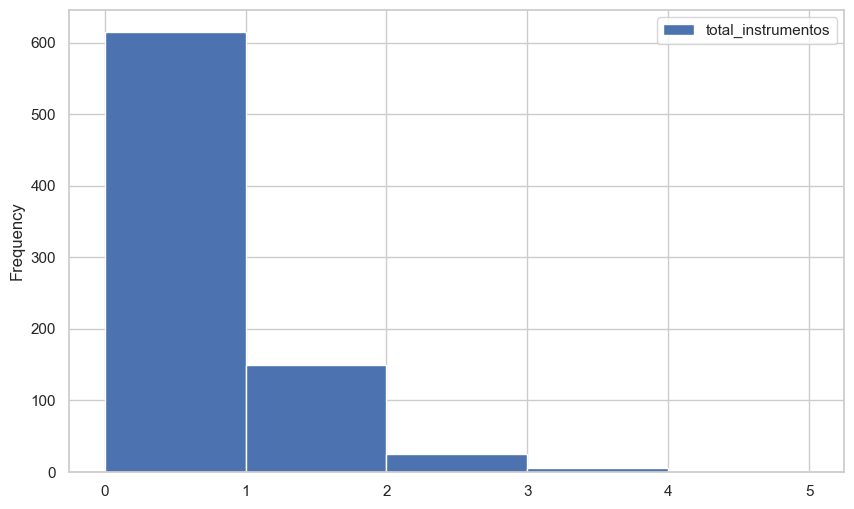

In [54]:
display(hinos_analise.sort_values("total_instrumentos", ascending=False).head(10))
hinos_analise.plot(
    kind="hist",
    y="total_instrumentos",
    bins=len(hinos_analise["total_instrumentos"].unique()),
    figsize=(10, 6),
)

,nome,texto,texto_processado,categoria_id,categoria,categoria_abr,texto_limpo,tokens,tokens_no_stops,num_tokens,texto_unico,num_tokens_unico,total_coro,total_instrumentos,total_final
numero,,,,,,,,,,,,,,,
790,AQUELE QUE HABITA NO ESCONDERIJO,AQUELE QUE HABITA\nNO ESCONDERIJO DO ALTÍSSIMO...,AQUELE QUE HABITA\nNO ESCONDERIJO DO ALTÍSSIMO...,11.0,CORINHOS,CORINHOS,AQUELE QUE HABITA NO ESCONDERIJO DO ALTÍSSIMO ...,"[aquele, que, habita, no, esconderijo, do, alt...","[habita, esconderijo, altíssimo, sombra, senho...",43,AQUELE QUE HABITA NO ESCONDERIJO DO ALTÍSSIMO ...,16,0,0,1
754,EU VEREI A ÁRVORE DA VIDA,"EU VEREI A ÁRVORE DA VIDA,\nEU VEREI O MEU LIN...","EU VEREI A ÁRVORE DA VIDA,\nEU VEREI O MEU LIN...",11.0,CORINHOS,CORINHOS,"EU VEREI A ÁRVORE DA VIDA, EU VEREI O MEU LIND...","[eu, verei, a, árvore, da, vida, eu, verei, o,...","[verei, árvore, vida, verei, lindo, país, vere...",103,"EU VEREI A ÁRVORE DA VIDA, EU VEREI O MEU LIND...",27,0,0,1
28,O PODER DO SANGUE DE JESUS,O PODER DO SANGUE DE JESUS\nHÁ DE ME PURIFICAR...,O PODER DO SANGUE DE JESUS\nHÁ DE ME PURIFICAR...,1.0,CLAMOR,CLAMOR,"O PODER DO SANGUE DE JESUS HÁ DE ME PURIFICAR,...","[o, poder, do, sangue, de, jesus, há, de, me, ...","[sangue, jesus, purificar, pecado, perdoar, dá...",100,"O PODER DO SANGUE DE JESUS HÁ DE ME PURIFICAR,...",31,2,0,1
27,CORDEIRO ETERNO,"CORDEIRO ETERNO, \nVIESTE PRA ME DAR\nTUA VIDA...","CORDEIRO ETERNO, \nVIESTE PRA ME DAR\nTUA VIDA...",1.0,CLAMOR,CLAMOR,"CORDEIRO ETERNO, VIESTE PRA ME DAR TUA VIDA, T...","[cordeiro, eterno, vieste, pra, me, dar, tua, ...","[cordeiro, eterno, vieste, dar, vida, sangue, ...",63,"CORDEIRO ETERNO, VIESTE PRA ME DAR TUA VIDA, T...",29,0,0,1
24,EIS O CORDEIRO DE DEUS,EIS O CORDEIRO DE DEUS\nQUE TIRA O PECADO DO M...,EIS O CORDEIRO DE DEUS\nQUE TIRA O PECADO DO M...,1.0,CLAMOR,CLAMOR,EIS O CORDEIRO DE DEUS QUE TIRA O PECADO DO MU...,"[eis, o, cordeiro, de, deus, que, tira, o, pec...","[eis, cordeiro, deus, tira, pecado, mundo, mor...",66,EIS O CORDEIRO DE DEUS QUE TIRA O PECADO DO MU...,31,2,0,1
730,SÓ TU NOS FAZES VENCEDORES,"SÓ TU NOS FAZES VENCEDORES,\nEM TI TEMOS FORÇA...","SÓ TU NOS FAZES VENCEDORES,\nEM TI TEMOS FORÇA...",10.0,GRUPO DE LOUVOR,GRUPO DE LOUVOR,"SÓ TU NOS FAZES VENCEDORES, EM TI TEMOS FORÇAS...","[só, tu, nos, fazes, vencedores, em, ti, temos...","[fazes, vencedores, forças, jornada, sacia, fo...",93,"SÓ TU NOS FAZES VENCEDORES, EM TI TEMOS FORÇAS...",20,0,1,1
729,OS TEUS ANJOS TE EXALTAM,"OS TEUS ANJOS TE EXALTAM, \nMEU SENHOR E REI,\...","OS TEUS ANJOS TE EXALTAM, \nMEU SENHOR E REI,\...",10.0,GRUPO DE LOUVOR,GRUPO DE LOUVOR,"OS TEUS ANJOS TE EXALTAM, MEU SENHOR E REI, CO...","[os, teus, anjos, te, exaltam, meu, senhor, e,...","[anjos, exaltam, senhor, rei, almejo, glória, ...",94,"OS TEUS ANJOS TE EXALTAM, MEU SENHOR E REI, CO...",44,0,0,1
728,NOSSA GRATIDÃO,NOSSA GRATIDÃO E NOSSO LOUVOR \nIREMOS DEIXAR ...,NOSSA GRATIDÃO E NOSSO LOUVOR \nIREMOS DEIXAR ...,10.0,GRUPO DE LOUVOR,GRUPO DE LOUVOR,NOSSA GRATIDÃO E NOSSO LOUVOR IREMOS DEIXAR NO...,"[nossa, gratidão, e, nosso, louvor, iremos, de...","[louvor, iremos, deixar, altar, daremos, senho...",112,NOSSA GRATIDÃO E NOSSO LOUVOR IREMOS DEIXAR NO...,58,0,0,1
727,EIS QUE ABRO A PORTA,EIS QUE ABRO A PORTA \nPRA DIZER AO POVO MEU: ...,EIS QUE ABRO A PORTA \nPRA DIZER AO POVO MEU: ...,10.0,GRUPO DE LOUVOR,GRUPO DE LOUVOR,EIS QUE ABRO A PORTA PRA DIZER AO POVO MEU: EN...,"[eis, que, abro, a, porta, pra, dizer, ao, pov...","[eis, abro, porta, dizer, povo, entra, vem, ce...",151,EIS QUE ABRO A PORTA PRA DIZER AO POVO MEU: EN...,37,0,1,1


<Axes: ylabel='Frequency'>

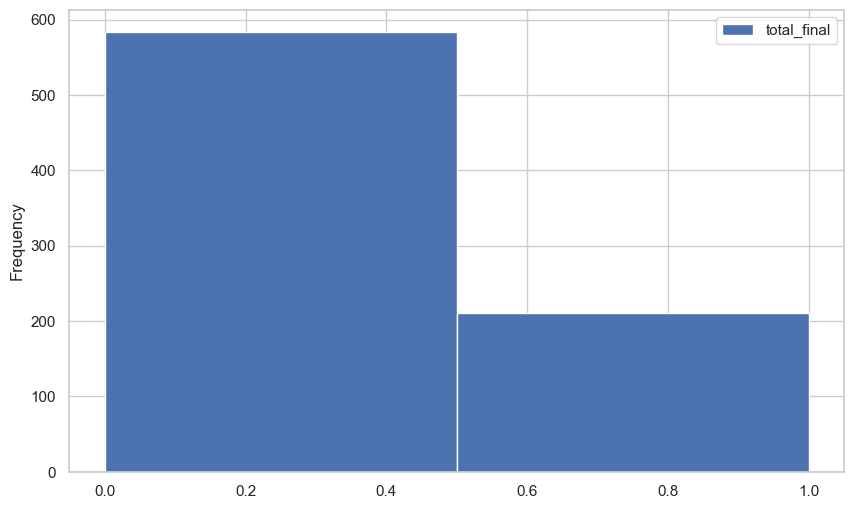

In [56]:
display(hinos_analise.sort_values("total_final", ascending=False).head(10))
hinos_analise.plot(
    kind="hist",
    y="total_final",
    bins=len(hinos_analise["total_final"].unique()),
    figsize=(10, 6),
)

In [57]:
# porcentagem de hinos com final
len(hinos_analise[hinos_analise["total_final"] > 0]) / len(hinos_analise) * 100

26.540880503144653